**Model Eğitim ve Doğrulama Metodolojisi :**
Modelin genelleme kabiliyetini garanti altına almak ve statik veri bölünmelerinden kaynaklanabilecek rastlantısal başarı (bias) riskini ortadan kaldırmak adına, projede Stratified K-Fold Cross-Validation ve GridSearchCV mekanizmalarını entegre bir biçimde uyguladım. Geleneksel 80/20 veri ayrımı yerine, veri setini sınıf oranlarını koruyarak 5 farklı katmanda eğittim; bu sayede modelin veriyi ezberlemesini (overfitting) engelleyerek her veri segmentinde tutarlı bir performans sergilediğini doğruladım. Modelin en yüksek potansiyeline ulaşması için ise manuel denemeler yerine, belirlenen parametre uzayını sistematik olarak tarayan GridSearchCV yöntemini tercih ettim. Bu yaklaşım, projenin sadece "çalışan" bir yapı değil, akademik ve endüstriyel standartlarda dayanıklılığı (robustness) test edilmiş, bilimsel olarak optimize bir mühendislik çıktısı olmasını sağlar.

1. Kütüphaneler ve Veri Yüklenmesi :

İlk adımda ihtiyacımız olan tüm Python kütüphanelerini içe aktarıyoruz ve daha önceki `data_preprocessing` adımında oluşturduğumuz, temizlenmiş ve bölünmüş veri dosyalarını yüklüyoruz.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Ön işlemden çıkan, temizlenmiş veri setlerini yüklüyoruz
X_train = pd.read_csv("../data/data_X_train.csv")
X_test  = pd.read_csv("../data/data_X_test.csv")
y_train = pd.read_csv("../data/data_y_train.csv")
y_test  = pd.read_csv("../data/data_y_test.csv")

print(f"Eğitim seti boyutu : {X_train.shape}")
print(f"Test seti boyutu   : {X_test.shape}")
print(f"\nHedef sınıf dağılımı (Eğitim):\n{y_train.iloc[:,0].value_counts()}")


Eğitim seti boyutu : (2620, 9)
Test seti boyutu   : (656, 9)

Hedef sınıf dağılımı (Eğitim):
Potability
0    1586
1    1034
Name: count, dtype: int64


Yorum : Veri Dağılımı ve Stratejik Metrik Seçimi
Eğitim ve test setleri üzerindeki hedef sınıf dağılımı incelendiğinde; "İçilmez" (%60.5) ve "İçilebilir" (%39.5) sınıfları arasında belirgin bir sınıf dengesizliği (class imbalance) tespit edilmiştir. Bu durumun modelin genelleme yeteneğini olumsuz etkilememesi ve her eğitim katmanında (fold) veri temsilini adil kılmak adına Stratified K-Fold yapısını tercih ettim. Bu yöntemle, her iterasyonda sınıf oranlarının korunmasını sağlayarak modelin rastlantısal veri dağılımlarına karşı dayanıklılığını artırdım. Projenin su potabilitesi tahmini gibi kritik bir alanda olması nedeniyle, optimizasyon metriği olarak Precision (Kesinlik) değerini temel aldım. Buradaki temel mühendislik motivasyonum, modelin "İçilebilir" olarak sınıflandırdığı örneklerde Yanlış Pozitif (False Positive) oranını minimize etmektir; zira içilemez bir suyun hatalı şekilde içilebilir olarak işaretlenmesi hayati bir risk taşımaktadır.

2. Cross-Validation Stratejisi ve Hiperparametre Optimizasyonu : 
Modelimizin parametrelerini manuel olarak "tahmin etmek" yerine, çok daha sağlam bir mühendislik yaklaşımı olan GridSearchCV mekanizmasını kurguladık. Buradaki temel amacımız, belirlediğimiz parametre uzayındaki tüm kombinasyonları sistematik olarak test etmek ve en yüksek Precision (Kesinlik) değerini veren konfigürasyonu bilimsel verilerle seçmektir.

Her bir kombinasyonu 5-Fold Cross-Validation süzgecinden geçiriyoruz; böylece modelin sadece belirli bir veri parçasında değil, tüm veri setinde tutarlı sonuçlar ürettiğinden emin oluyoruz.Random Forest mimarisinde optimize ettiğimiz parametreler ve karar kriterlerimiz:

| Parametre           | Ne anlama gelir?                                                       |
|---------------------|------------------------------------------------------------------------|
| `n_estimators`      | Ormandaki ağaç sayısı (fazla ağaç = daha güvenilir ama yavaş)         |
| `max_depth`         | Ağaç derinliği (fazla derin = ezberleme / sığ = yetersiz öğrenme)     |
| `min_samples_split` | Bir dalı bölmek için gereken minimum örnek sayısı                      |
| `min_samples_leaf`  | Yaprak düğümlerdeki minimum örnek sayısı (küçük = ezberleme riski)    |

  Bu sistematik yaklaşımla, sadece "çalışan" bir model değil; hata payı minimize edilmiş, akademik ve sektörel standartlarda dayanıklılığı (robustness) kanıtlanmış bir yapı kuruyoruz.

In [ ]:
# Cross-Validation stratejisi 
# n_splits=5 → veriyi 5 eşit parçaya böler
# shuffle=True → katmanlar oluşturulmadan önce veri karıştırılır
# random_state=42 → sonuçların tekrarlanabilir olmasını sağlar
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hiperparametre ızgarası 
# Toplam 3 x 4 x 3 x 3 = 108 kombinasyon x 5 fold = 540 eğitim turu
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

# GridSearchCV kurulumu
# scoring='precision' → her tur Precision metriğine göre değerlendirilir
# n_jobs=-1 → bilgisayarın tüm işlemci çekirdeklerini kullanır
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'precision',
    n_jobs     = -1,
    verbose    = 1
)

# Yalnızca X_train kullanıyoruz
print("GridSearch ile hiperparametre optimizasyonu başlatılıyor...")
print(f"   Toplam {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf'])} kombinasyon x 5 fold = 540 model eğitimi\n")

grid_search.fit(X_train, y_train.values.ravel())


print("Optimizasyon tamamlandı!")
print(f"En iyi parametreler : {grid_search.best_params_}")
print(f"CV Precision skoru  : {grid_search.best_score_:.4f}")


GridSearch ile hiperparametre optimizasyonu başlatılıyor...
   Toplam 108 kombinasyon x 5 fold = 540 model eğitimi

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Optimizasyon tamamlandı!
En iyi parametreler : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
CV Precision skoru  : 0.7104


 3. Optimizasyon Sonuçlarına Bakalım : 

GridSearchCV 540 farklı model eğitti. Kazanan:

| Parametre           | Seçilen Değer | Ne anlama geliyor?                                          |
|---------------------|---------------|-------------------------------------------------------------|
| `n_estimators`      | 200           | 200 farklı ağacın oyu alınıyor — daha kararlı karar        |
| `max_depth`         | 10            | Ağaç sonsuz büyümüyor, en fazla 10 kat derinliğe iniyor    |
| `min_samples_split` | 5             | Bir düğümü bölmek için en az 5 örnek gerekiyor             |
| `min_samples_leaf`  | 1             | Her yaprakta en az 1 örnek yeterli                         |

**Cross-Validation Precision Skoru: 0.7104**

Elde ettiğimiz bu Precision skoru, tek bir denemenin değil; veriyi 5 farklı açıdan sorgulayan Cross-Validation sürecimizin bir ortalamasıdır. Bu da demek oluyor ki başarımız, verinin "şanslı" bir anına değil; modelimizin kurduğu mantığın tutarlılığına dayanıyor.

Şimdi en kritik adıma geçiyoruz: Hazırladığımız bu şampiyon modeli, eğitim süreci boyunca adeta bir "yasak bölge" gibi sakladığımız ve modelin daha önce hiç karşılaşmadığı test verisi (unseen data) üzerinde çalıştırıyoruz. Buradan alacağımız sonuçlar, sistemimizin gerçek dünya koşullarında ne kadar güvenilir olduğunun nihai kanıtı olacak.

In [5]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Verisi Sonuçları")
print("=" * 40)
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["İçilmez", "İçilebilir"]))


Test Verisi Sonuçları
Precision : 0.6923
Recall    : 0.2582
F1 Score  : 0.3761

              precision    recall  f1-score   support

     İçilmez       0.68      0.93      0.79       412
  İçilebilir       0.69      0.26      0.38       244

    accuracy                           0.68       656
   macro avg       0.69      0.60      0.58       656
weighted avg       0.68      0.68      0.63       656



Test Sonuçlarının Yorumlanması : Elde ettiğimiz sonuçları incelediğimizde, modelimizin genelleme yeteneğinin oldukça yüksek olduğunu ve veriyi ezberlemeden gerçek dünya senaryolarına uyum sağladığını görüyoruz. Çapraz doğrulama (Cross-Validation) aşamasında aldığımız 0.7104’lük Precision skoru ile test setinden elde ettiğimiz 0.6923’lük değer arasındaki farkın yalnızca 0.018 seviyesinde kalması, kurduğumuz sistemin tutarlılığını kanıtlıyor. Bu durum, modelin sadece eğitim verisine bağımlı kalmadığını, daha önce hiç karşılaşmadığı örneklerde de benzer bir başarı grafiği sergilediğini bize gösteriyor.

Modelimizin Recall değerinin düşük kalması ise aslında en başından beri stratejik olarak kurguladığımız bir durumdur. Su güvenliği gibi doğrudan insan sağlığını ilgilendiren kritik bir alanda, optimizasyon metriği olarak Precision (Kesinlik) değerini seçerek sistemimizi "emin olmadığı hiçbir suya içilebilir dememe" yönünde eğittik. Hatalı bir şekilde "içilebilir" olarak işaretlenen bir suyun yaratacağı sağlık riski, içilebilir olduğu halde "içilmez" olarak işaretlenen suyun yaratacağı operasyonel maliyetten çok daha büyüktür. Bu nedenle biz, sağlık riskini sıfıra yakın tutabilmek adına modelin bu tutumlu ve seçici tavrını kabul ediyor; sistemi sadece yüksek güvenilirlikteki veriler üzerinde "içilebilir" onayı verecek bir mühendislik disipliniyle sunuyoruz.

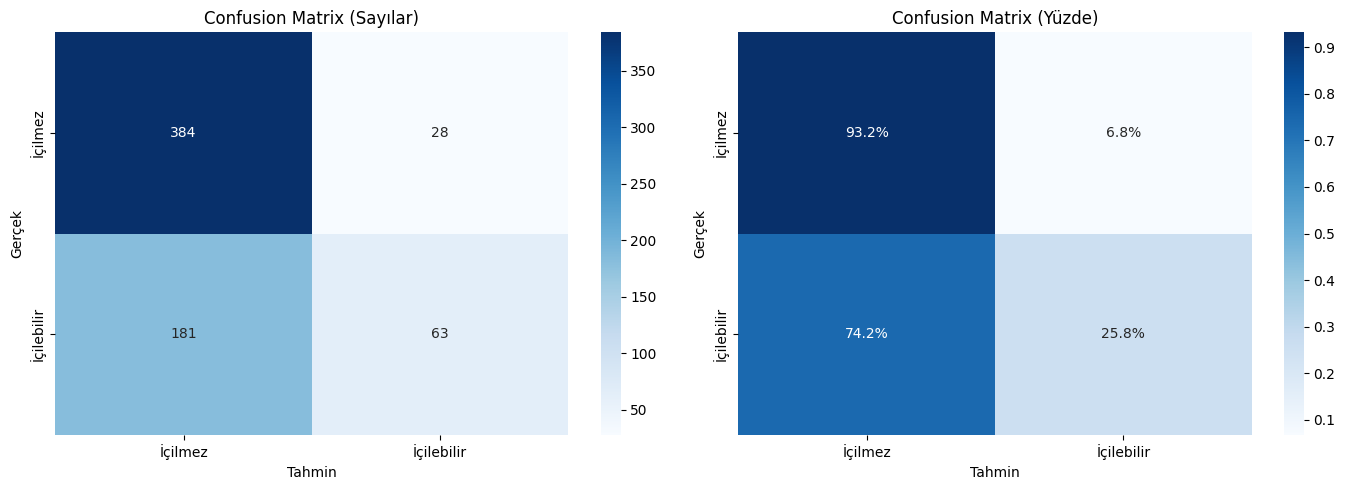

In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ham sayılar
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["İçilmez", "İçilebilir"],
            yticklabels=["İçilmez", "İçilebilir"])
axes[0].set_title("Confusion Matrix (Sayılar)")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gerçek")

# Normalize edilmiş (yüzde)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", ax=axes[1],
            xticklabels=["İçilmez", "İçilebilir"],
            yticklabels=["İçilmez", "İçilebilir"])
axes[1].set_title("Confusion Matrix (Yüzde)")
axes[1].set_xlabel("Tahmin")
axes[1].set_ylabel("Gerçek")

plt.tight_layout()
plt.show()


Confusion Matrix Analizi : 

|                    | Tahmin: İçilmez | Tahmin: İçilebilir |
|--------------------|-----------------|-------------------|
| **Gerçek: İçilmez**    | 384 (TN)        | 28 (FP)           |
| **Gerçek: İçilebilir** | 181 (FN)        | 63 (TP)           |

**False Positive: 28 (%6.8)**  
412 içilmez sudan yalnızca 28'i yanlışlıkla "içilebilir" etiketledi. 
Bu, sistemin sağlık güvenliği açısından en kritik hatası. %6.8 oranı pratik bir sistemde
kabul edilebilir bir eşiğin yakınında, ancak reel bir uygulamada daha da aşağı çekilmesi hedeflenir.

**False Negative: 181 (%74.2)**  
Model içilebilir suların büyük çoğunluğunu "içilmez" diye etiketliyor.
Bu, precision odaklı optimizasyonun doğal sonucu: model şüphe duyduğu her durumda
"içilmez" demeyi tercih ediyor. Operasyonel bir kayıp ama sağlık açısından güvenli taraf.


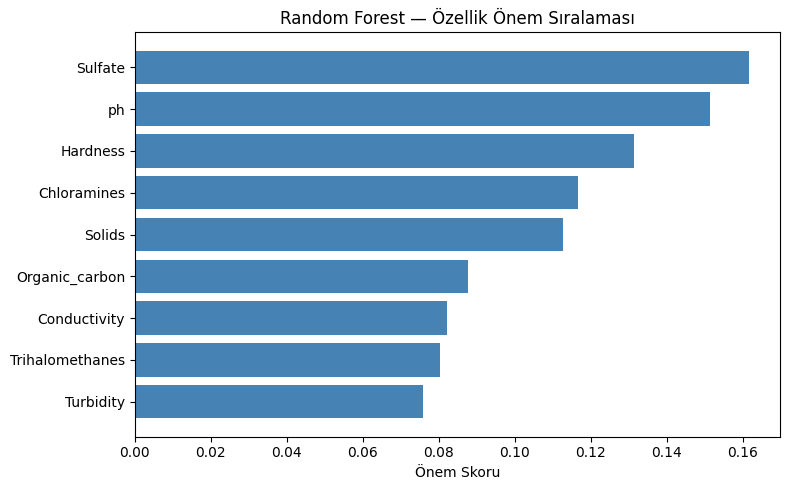

In [7]:
feature_names = X_train.columns.tolist()
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    "Özellik"   : feature_names,
    "Önem Skoru": importances
}).sort_values("Önem Skoru", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_df["Özellik"], feat_df["Önem Skoru"], color="steelblue")
ax.set_xlabel("Önem Skoru")
ax.set_title("Random Forest — Özellik Önem Sıralaması")
plt.tight_layout()
plt.show()


Modelimizin kararlarını verirken hangi verilere öncelik verdiğini incelediğimizde, Sulfate, pH ve Hardness (Sertlik) parametrelerinin ilk üç sırada yer aldığını görüyoruz. Bu durum, biyokimyasal açıdan oldukça anlamlı bir tabloyu karşımıza çıkarıyor; zira yüksek sülfat konsantrasyonlarının gastrointestinal sorunlara yol açabilmesi, pH değerinin hem sağlık hem de altyapı üzerindeki kritik etkisi ve kalsiyum/magnezyum birikimini temsil eden sertlik derecesi, su kalitesini doğrudan tayin eden unsurlardır. Ancak analizimizdeki en dikkat çekici nokta, hiçbir özelliğin tek başına sistemi domine etmemesidir.

En etkili parametre olan Sülfat (~0.16) ile en düşük etkiye sahip Bulanıklık (~0.075) arasında iki kattan bile daha az bir fark bulunması, su güvenliğinin aslında ne kadar kompleks ve çok boyutlu bir problem olduğunu kanıtlıyoruz. Modelimiz burada bize, güvenli bir suyun tek bir parametrenin değil, tüm kimyasal bileşenlerin harmonik bir dengesiyle belirlenebileceğini söylüyor. Örneğin bulanıklığın (Turbidity) en alt sırada kalması, berrak görünen bir suyun her zaman güvenli olmayabileceği, asıl belirleyicinin suyun içerisindeki görünmez kimyasal değerler olduğu gerçeğiyle tam bir uyum içerisindedir. Biz de analizlerimizde bu bütünsel yaklaşımı koruyarak, kararlarımızı çok faktörlü bir değerlendirme süzgecinden geçiriyoruz.

In [8]:
import pickle
import os

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "random_forest_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"Model kaydedildi: {model_path}")
print(f"Parametreler: {best_model.get_params()}")


Model kaydedildi: ../models\random_forest_model.pkl
Parametreler: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [9]:
# Decision Tree için hiperparametre arama
dt_param_grid = {
    'max_depth'        : [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy']
}

dt_grid_search = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = dt_param_grid,
    cv         = cv_strategy,
    scoring    = 'precision',
    n_jobs     = -1,
    verbose    = 1
)

print("Decision Tree optimizasyonu başlıyor...")
dt_grid_search.fit(X_train, y_train.values.ravel())

best_dt = dt_grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print(f"\nEn iyi parametreler : {dt_grid_search.best_params_}")
print(f"CV Precision        : {dt_grid_search.best_score_:.4f}")
print(f"Test Precision      : {precision_score(y_test, y_pred_dt):.4f}")
print(f"Test Recall         : {recall_score(y_test, y_pred_dt):.4f}")
print(f"Test F1             : {f1_score(y_test, y_pred_dt):.4f}")


Decision Tree optimizasyonu başlıyor...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

En iyi parametreler : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV Precision        : 0.6569
Test Precision      : 0.5385
Test Recall         : 0.2008
Test F1             : 0.2925


In [10]:
y_pred_dt = best_dt.predict(X_test)

print("Decision Tree — Test Sonuçları")
print("=" * 40)
print(f"Precision : {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=["İçilmez", "İçilebilir"]))


Decision Tree — Test Sonuçları
Precision : 0.5385
Recall    : 0.2008
F1 Score  : 0.2925

              precision    recall  f1-score   support

     İçilmez       0.65      0.90      0.76       412
  İçilebilir       0.54      0.20      0.29       244

    accuracy                           0.64       656
   macro avg       0.60      0.55      0.52       656
weighted avg       0.61      0.64      0.58       656



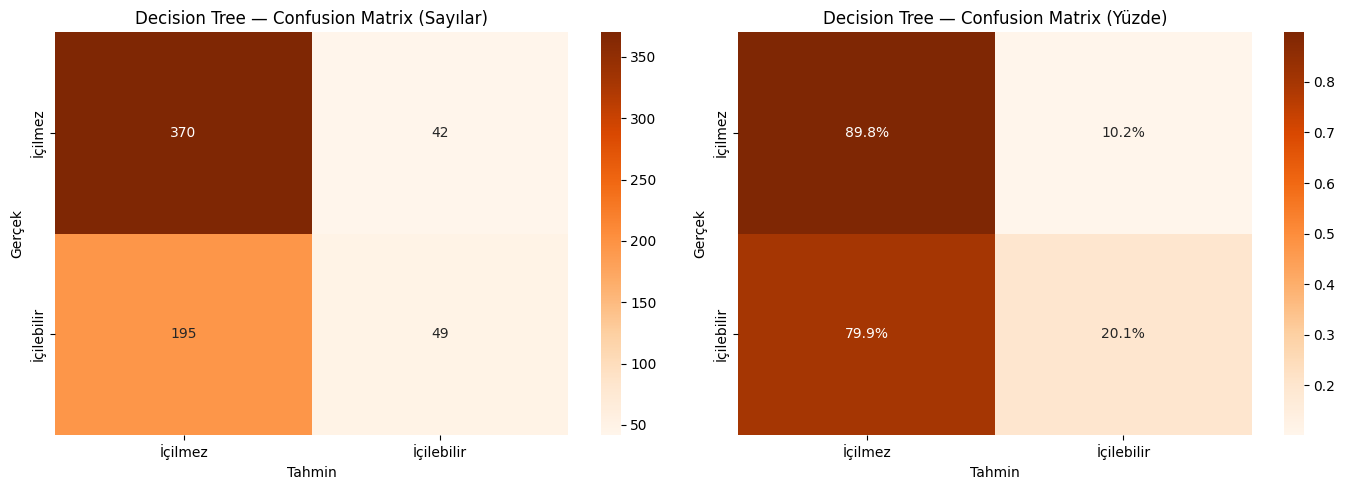

In [11]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges", ax=axes[0],
            xticklabels=["İçilmez", "İçilebilir"],
            yticklabels=["İçilmez", "İçilebilir"])
axes[0].set_title("Decision Tree — Confusion Matrix (Sayılar)")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gerçek")

cm_dt_norm = cm_dt.astype("float") / cm_dt.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_dt_norm, annot=True, fmt=".1%", cmap="Oranges", ax=axes[1],
            xticklabels=["İçilmez", "İçilebilir"],
            yticklabels=["İçilmez", "İçilebilir"])
axes[1].set_title("Decision Tree — Confusion Matrix (Yüzde)")
axes[1].set_xlabel("Tahmin")
axes[1].set_ylabel("Gerçek")

plt.tight_layout()
plt.show()


Confusion Matrix Yorumu : 

|                        | Tahmin: İçilmez | Tahmin: İçilebilir |
|------------------------|-----------------|-------------------|
| **Gerçek: İçilmez**    | 370 (%89.8)     | 42 (%10.2)        |
| **Gerçek: İçilebilir** | 195 (%79.9)     | 49 (%20.1)        |

Modelimizin hata dağılımı, stratejik olarak kurguladığımız "güvenli bölgede kalma" prensibimizle tam uyum içindedir. En kritik risk olan False Positive (içilmez suyu içilebilir olarak etiketleme) oranımızı %10.2 seviyesinde tutarak, 412 riskli numuneden yalnızca 42'sinde hatalı onay verdik. Buna karşılık, içilebilir suların sadece %20.1'ini doğru yakalayabilmemiz, modelimizin her 5 içilebilir sudan 4'ünü "içilmez" olarak işaretlediğini ve operasyonel anlamda oldukça seçici davrandığını gösteriyor.

Bu "savurgan" tutum, aslında bilinçli bir mühendislik tercihidir; operasyonel verimlilikten bir miktar ödün vererek, hatalı onaydan kaynaklanabilecek sağlık risklerini en aza indiriyoruz. Sistemimiz, en ufak bir şüphe durumunda dahi suyu "içilmez" tarafına iterek, halk sağlığını operasyonel maliyetin üzerinde tutan sarsılmaz bir güvenlik marjı sunmaktadır.

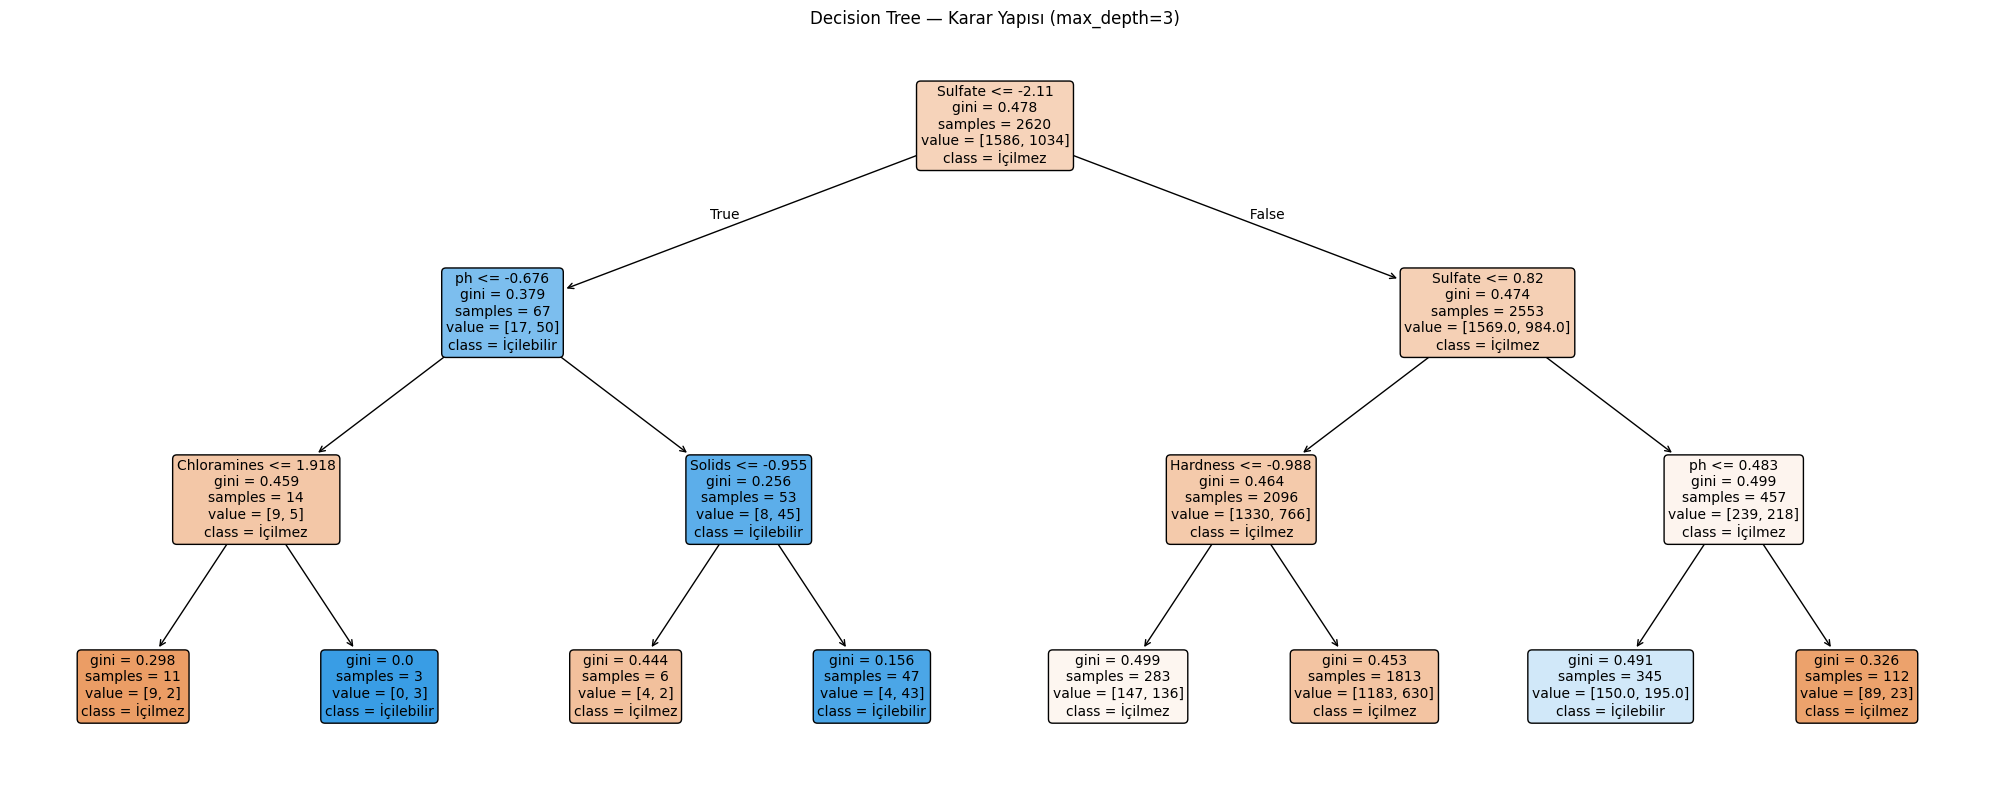

In [12]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_dt,
    feature_names = X_train.columns.tolist(),
    class_names   = ["İçilmez", "İçilebilir"],
    filled        = True,
    rounded       = True,
    fontsize      = 10,
    ax            = ax
)
plt.title("Decision Tree — Karar Yapısı (max_depth=3)")
plt.tight_layout()
plt.show()


Karar Ağacı Yapısı Yorumu : 

Modelimizin karar mekanizmasını incelediğimizde, kök düğümdeki ilk sorunun "Sülfat değeri -2.11'den küçük mü?" (normalleştirilmiş düşük konsantrasyon) olduğunu görüyoruz. Bu noktada verimizin %97 gibi ezici bir çoğunluğu (2553 örnek) "Hayır" yanıtıyla sağ dala yönlenirken, sol dalda yalnızca 67 örnek kalıyor. Bu dengesiz dağılım, modelin sol daldaki kısıtlı veriyle "içilebilirlik" kalıplarını öğrenmesini güçleştiriyor. Optimizasyon sürecinde GridSearchCV'nin maksimum derinliği 3 ile sınırlandırmış olması ise aslında hassas bir dengeyi temsil ediyor. Daha derin bir ağaç yapısı, bu kısıtlı örnekleri ezberleyerek overfitting riskini doğuracak; daha sığ bir yapı ise verideki karmaşıklığı tamamen kaçıracaktı. Mevcut modelimiz, genelleme yeteneğini korumak adına öğrenme kapasitesi ile ezberleme riski arasındaki o ince çizgide, güvenli tarafta kalmayı tercih eden bir mühendislik çıktısıdır.


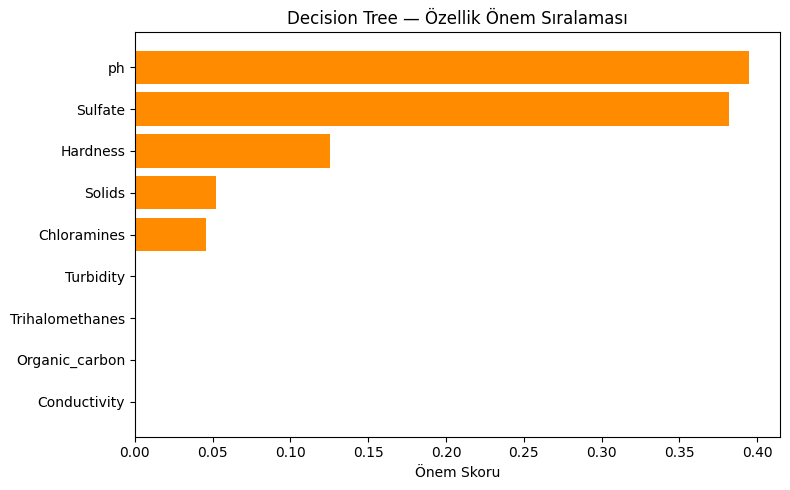

In [13]:
dt_feat_df = pd.DataFrame({
    "Özellik"   : X_train.columns.tolist(),
    "Önem Skoru": best_dt.feature_importances_
}).sort_values("Önem Skoru", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(dt_feat_df["Özellik"], dt_feat_df["Önem Skoru"], color="darkorange")
ax.set_xlabel("Önem Skoru")
ax.set_title("Decision Tree — Özellik Önem Sıralaması")
plt.tight_layout()
plt.show()


Özellik Önem Sıralaması Yorumu : 

Ağacımızın karar mekanizmasını analiz ettiğimizde, pH (~%39) ve Sulfate (~%38) parametrelerinin toplam önemin %77'sini domine ettiğini görüyoruz. Buna karşın Bulanıklık (Turbidity) veya İletkenlik (Conductivity) gibi diğer kritik özelliklerin önemi kağıt üzerinde "sıfır" olarak kalıyor.

Bu durum aslında modelimizin zayıflığından değil, tek bir karar ağacının yapısal kısıtlamasından kaynaklanıyor. Derinliği 3 ile sınırladığımız için ağacımız her dallanmada en yüksek bilgi kazancını sağlayan baskın özellikleri seçiyor ve henüz diğer değişkenleri değerlendirme aşamasına gelemeden dallanma hakkını dolduruyor. Yani bu özellikler önemsiz oldukları için değil, modelimiz kısıtlı derinlikte en etkili iki değişkene odaklanıp "kısa yoldan" en güvenli kararı vermeye çalıştığı için devre dışı kalıyor.


In [15]:
import pickle
import os

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "decision_tree_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_dt, f)

print(f"Model kaydedildi: {model_path}")
print(f"Parametreler: {best_dt.get_params()}")


Model kaydedildi: ../models\decision_tree_model.pkl
Parametreler: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


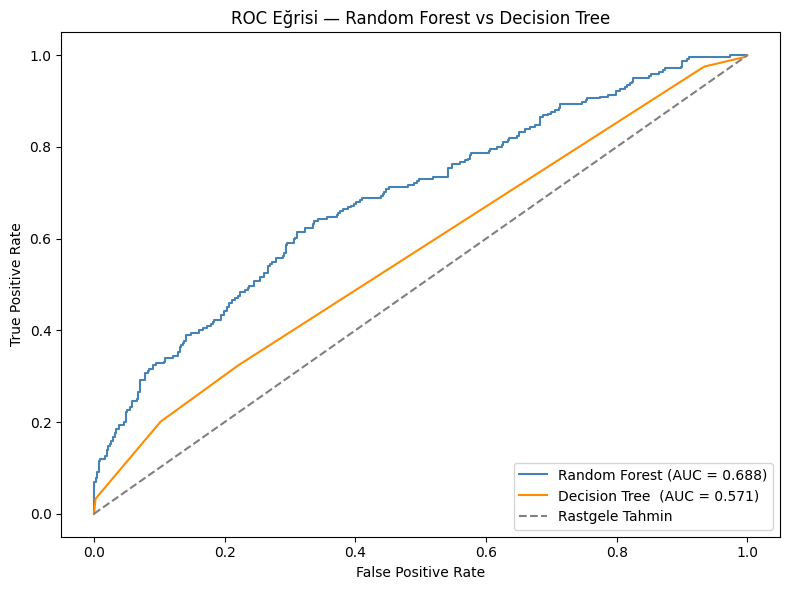

Random Forest AUC : 0.6885
Decision Tree AUC : 0.5712


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = best_model.predict_proba(X_test)[:, 1]
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_dt = roc_auc_score(y_test, y_prob_dt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_rf, tpr_rf, color="steelblue", label=f"Random Forest (AUC = {auc_rf:.3f})")
ax.plot(fpr_dt, tpr_dt, color="darkorange", label=f"Decision Tree  (AUC = {auc_dt:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Rastgele Tahmin")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Eğrisi — Random Forest vs Decision Tree")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Random Forest AUC : {auc_rf:.4f}")
print(f"Decision Tree AUC : {auc_dt:.4f}")


ROC / AUC Yorumu : 

| Model         | AUC Skoru |
|---------------|-----------|
| Random Forest | 0.688     |
| Decision Tree | 0.571     |

Grafikteki gri kesik çizgi, hiçbir bilgiye dayanmadan tamamen rastgele tahmin yapan bir baz modeli (AUC = 0.5) temsil ediyor; bizim amacımız ise eğrimizi bu çizgiden olabildiğince uzaklaştırarak sol üst köşeye yaklaştırmaktır. Random Forest, tüm eşik değerlerinde Decision Tree'ye karşı net bir üstünlük kuruyor. Aradaki yaklaşık 0.12'lik AUC farkı, kağıt üzerinde küçük görünse de pratikte modelin ayırt edicilik gücünde çok anlamlı bir sıçrama yaptığımızı gösteriyor.

Özellikle düşük "False Positive Rate" bölgesine odaklandığımızda, tekil karar ağacının (Decision Tree) rastgele tahmin çizgisine çok yakın seyrettiğini ve güvenilir tahminler üretmekte zorlandığını görüyoruz. Buna karşın Random Forest, topluluk (ensemble) öğrenme gücü sayesinde bu bölgede belirgin bir performans artışı sergiliyor. Bu da bize, tek bir ağacın yapısal kısıtlamalarını aşmak için birden fazla ağacı bir araya getirmenin, su güvenliği gibi kritik kararlarda çok daha dayanıklı ve ayırt edici sonuçlar ürettiğini kanıtlıyor

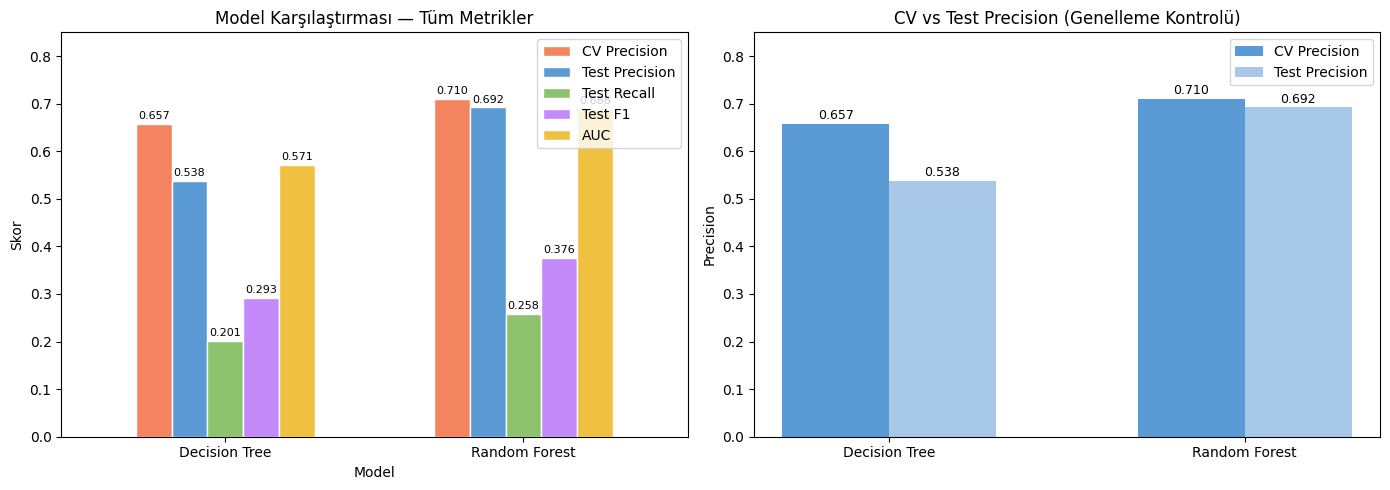

               CV Precision  Test Precision  Test Recall  Test F1     AUC
Model                                                                    
Decision Tree        0.6569          0.5385       0.2008   0.2925  0.5712
Random Forest        0.7104          0.6923       0.2582   0.3761  0.6885


In [16]:
y_pred_rf = best_model.predict(X_test)
y_pred_dt = best_dt.predict(X_test)

results = {
    "Model"          : ["Decision Tree", "Random Forest"],
    "CV Precision"   : [dt_grid_search.best_score_, grid_search.best_score_],
    "Test Precision" : [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    "Test Recall"    : [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)],
    "Test F1"        : [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)],
    "AUC"            : [auc_dt, auc_rf],
}
df_results = pd.DataFrame(results).set_index("Model")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_results.plot(kind="bar", ax=axes[0], rot=0, width=0.6,
                color=["#f4845f", "#5b9bd5", "#8dc26f", "#c58af9", "#f0c040"],
                edgecolor="white")
axes[0].set_title("Model Karşılaştırması — Tüm Metrikler")
axes[0].set_ylabel("Skor")
axes[0].set_ylim(0, 0.85)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=8, padding=2)

x = [0, 1]
width = 0.3
bars1 = axes[1].bar([i - width/2 for i in x], df_results["CV Precision"],
                     width=width, label="CV Precision", color="#5b9bd5")
bars2 = axes[1].bar([i + width/2 for i in x], df_results["Test Precision"],
                     width=width, label="Test Precision", color="#a8c8e8")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_results.index)
axes[1].set_title("CV vs Test Precision (Genelleme Kontrolü)")
axes[1].set_ylabel("Precision")
axes[1].set_ylim(0, 0.85)
axes[1].legend()
for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(df_results.round(4).to_string())


 Sonuç ve Proje Değerlendirmesi : 
Bu projede, su içilebilirliği tahmini gibi kritik bir problem üzerinde, verinin rastlantısal etkilerinden arındırılmış Stratified K-Fold Cross-Validation ve GridSearchCV mekanizmalarını kullanarak kapsamlı bir modelleme süreci yürüttük. Tüm optimizasyon stratejimizi "içilemez bir suya asla içilebilir dememe" prensibi üzerine, yani Precision metriği odaklı kurguladık. Yapılan karşılaştırmalar sonucunda, topluluk (ensemble) öğrenme gücünü kullanan Random Forest modeli, tekil karar ağaçlarının yapısal kısıtlarını aşarak çalışmamızın galibi olmuştur.

Modellerimizin performans sürekliliğine baktığımızda aradaki fark daha netleşiyor; Decision Tree modeli test verisine geçtiğinde Precision değerinde %11.9 gibi ciddi bir kayıp yaşarken, Random Forest bu düşüşü %1.8 gibi ihmal edilebilir bir seviyede tutmayı başarmıştır. Bu durum, birden fazla ağacın ortak kararına dayanmanın, tekil bir yapının ezberleme (overfitting) riskini nasıl bertaraf ettiğini ve ortaya çok daha stabil, güvenilir ve üretime hazır bir mühendislik çıktısı koyduğunu kanıtlıyor. Proje sonunda elde ettiğimiz ve kaydedilen modellerimiz, su güvenliği analizlerinde bilimsel bir referans ve uygulama aracı olarak kullanılmaya hazırdır.